In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
data = pd.read_csv(r"C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/data/Synthetic_Financial_datasets_log.csv")


In [14]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [16]:
data.shape

(6362620, 11)

In [18]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [22]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [24]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [28]:
data['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [36]:
# Verify isFlaggedFraud vs isFraud
print(data['isFlaggedFraud'].value_counts())


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [38]:
print(data[(data['isFlaggedFraud'] == 1) & (data['isFraud'] == 1)].shape[0])
#how many flagged  and actually it was fraud


16


In [40]:
print(data[(data['isFlaggedFraud'] == 0) & (data['isFraud'] == 1)].shape[0])#how many flag did it miss

8197


In [44]:
data= data.drop('isFlaggedFraud',axis = 1)

In [46]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [52]:
data = data.drop('nameOrig',axis = 1)

In [54]:
data = data.drop('nameDest',axis = 1)

In [56]:
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


In [58]:
data['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [62]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [64]:
data.duplicated().sum()

543

In [66]:
data = data.drop_duplicates()

In [70]:
data.duplicated().sum()

0

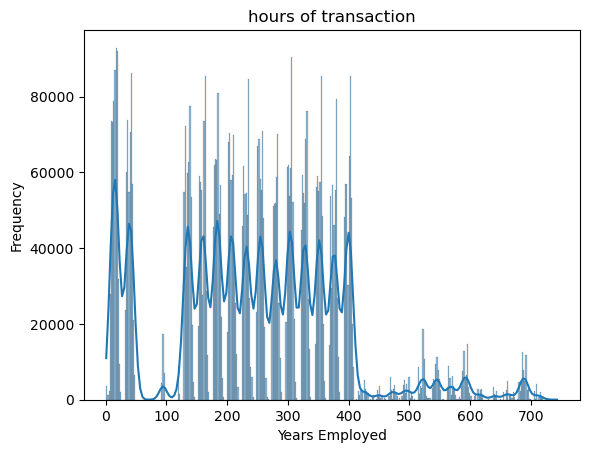

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['step'], kde=True)

plt.title("hours of transaction")
plt.xlabel("Years Employed")
plt.ylabel("Frequency")

plt.show()

In [79]:
print(data.groupby('isFraud')['amount'].describe())

fraud_mean    = data[data['isFraud']==1]['amount'].mean()
nonfraud_mean = data[data['isFraud']==0]['amount'].mean()

print(f"Fraud avg amount:     {fraud_mean:,.2f}")
print(f"Non-Fraud avg amount: {nonfraud_mean:,.2f}")

             count          mean           std   min          25%        50%  \
isFraud                                                                        
0        6353880.0  1.782112e+05  5.962597e+05  0.01   13372.5075   74700.91   
1           8197.0  1.452533e+06  2.378653e+06  0.00  126848.6300  438859.10   

                75%          max  
isFraud                           
0         208379.04  92445516.64  
1        1503297.45  10000000.00  
Fraud avg amount:     1,452,533.30
Non-Fraud avg amount: 178,211.22


In [207]:
'''import numpy as np

# Compress the scale without losing outlier information
data.loc[:,'amount_log'] = np.log1p(data['amount'])

# Visualize again - much cleaner!
sns.boxplot(data['amount_log'])'''

"import numpy as np\n\n# Compress the scale without losing outlier information\ndata.loc[:,'amount_log'] = np.log1p(data['amount'])\n\n# Visualize again - much cleaner!\nsns.boxplot(data['amount_log'])"

In [211]:
data

,step,type,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,amount_log,balanceDropOrig,balanceGainDest,origBalanceZero,isHighRiskType
0,1,PAYMENT,170136.00,160296.36,0.00,0.00,0,9.194276,9839.64,0.00,0,0
1,1,PAYMENT,21249.00,19384.72,0.00,0.00,0,7.531166,1864.28,0.00,0,0
2,1,TRANSFER,181.00,0.00,0.00,0.00,1,5.204007,181.00,0.00,1,1
3,1,CASH_OUT,181.00,0.00,21182.00,0.00,1,5.204007,181.00,-21182.00,1,1
4,1,PAYMENT,41554.00,29885.86,0.00,0.00,0,9.364703,11668.14,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,0.00,0.00,339682.13,1,12.735768,339682.13,339682.13,1,1
6362616,743,TRANSFER,6311409.28,0.00,0.00,0.00,1,15.657870,6311409.28,0.00,1,1
6362617,743,CASH_OUT,6311409.28,0.00,68488.84,6379898.11,1,15.657870,6311409.28,6311409.27,1,1
6362618,743,TRANSFER,850002.52,0.00,0.00,0.00,1,13.652996,850002.52,0.00,1,1


In [213]:
"""The amount column had extreme right skewness — most transactions were small but a few went up to 92 million. This large scale difference confuses ML models. We applied log1p to compress the scale while preserving the pattern. We used log1p specifically instead of log because some transactions had zero amount, and log(0) is undefined — log1p handles that safely by computing log(1+x)."""


'The amount column had extreme right skewness — most transactions were small but a few went up to 92 million. This large scale difference confuses ML models. We applied log1p to compress the scale while preserving the pattern. We used log1p specifically instead of log because some transactions had zero amount, and log(0) is undefined — log1p handles that safely by computing log(1+x).'

In [215]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6362077 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   type             object 
 2   oldbalanceOrg    float64
 3   newbalanceOrig   float64
 4   oldbalanceDest   float64
 5   newbalanceDest   float64
 6   isFraud          int64  
 7   amount_log       float64
 8   balanceDropOrig  float64
 9   balanceGainDest  float64
 10  origBalanceZero  int32  
 11  isHighRiskType   int32  
dtypes: float64(7), int32(2), int64(2), object(1)
memory usage: 711.5+ MB


In [219]:
#data = data.drop('amount',axis = 1)

In [221]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder

In [223]:
categorical_cols = ['type']
numerical_cols = ['step','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','amount_log']


In [225]:
preprocessor = ColumnTransformer(transformers = [
    ('cat',OneHotEncoder(),categorical_cols),
    ('num',StandardScaler(),numerical_cols)])

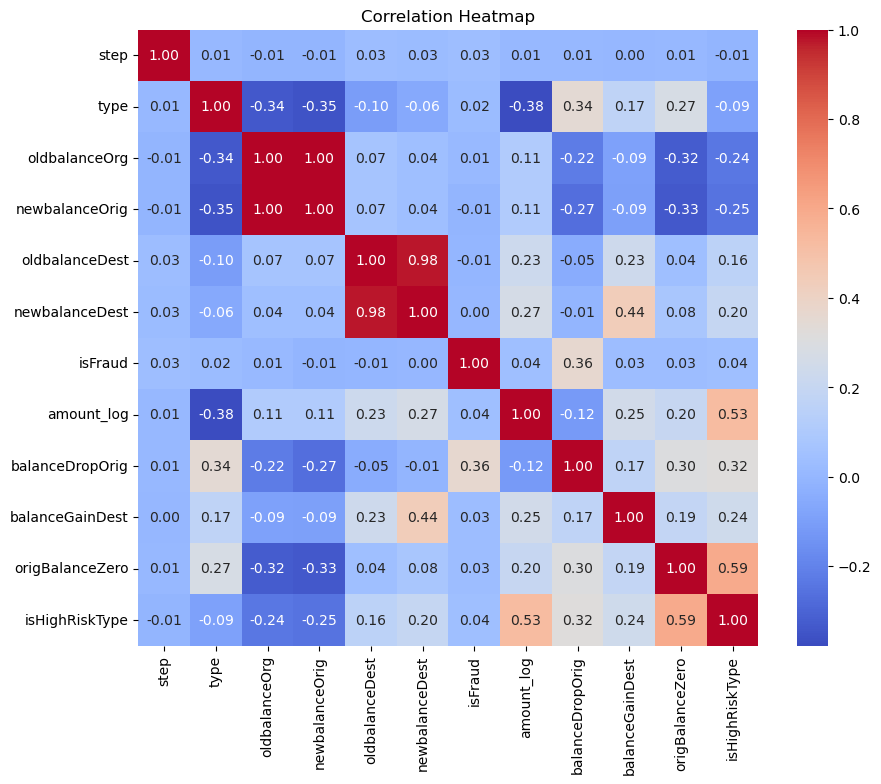

In [227]:
# Just for heatmap - don't touch original data
data_corr = data.copy()
data_corr['type'] = data_corr['type'].map({
    'CASH_IN': 0, 'CASH_OUT': 1, 
    'DEBIT': 2, 'PAYMENT': 3, 'TRANSFER': 4
})

plt.figure(figsize=(10, 8))
sns.heatmap(data_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [228]:
data


,step,type,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,amount_log,balanceDropOrig,balanceGainDest,origBalanceZero,isHighRiskType
0,1,PAYMENT,170136.00,160296.36,0.00,0.00,0,9.194276,9839.64,0.00,0,0
1,1,PAYMENT,21249.00,19384.72,0.00,0.00,0,7.531166,1864.28,0.00,0,0
2,1,TRANSFER,181.00,0.00,0.00,0.00,1,5.204007,181.00,0.00,1,1
3,1,CASH_OUT,181.00,0.00,21182.00,0.00,1,5.204007,181.00,-21182.00,1,1
4,1,PAYMENT,41554.00,29885.86,0.00,0.00,0,9.364703,11668.14,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,0.00,0.00,339682.13,1,12.735768,339682.13,339682.13,1,1
6362616,743,TRANSFER,6311409.28,0.00,0.00,0.00,1,15.657870,6311409.28,0.00,1,1
6362617,743,CASH_OUT,6311409.28,0.00,68488.84,6379898.11,1,15.657870,6311409.28,6311409.27,1,1
6362618,743,TRANSFER,850002.52,0.00,0.00,0.00,1,13.652996,850002.52,0.00,1,1


In [231]:
"""lets go for feature  engineering"""


'lets go for feature  engineering'

In [233]:
data['balanceDropOrig'] = data['oldbalanceOrg']-data['newbalanceOrig']

In [235]:
data['balanceGainDest'] = data['newbalanceDest']-data['oldbalanceDest']

In [237]:
data['origBalanceZero'] = (data['newbalanceOrig'] == 0).astype(int)

In [239]:
data['isHighRiskType'] = data['type'].isin(['CASH_OUT','TRANSFER']).astype(int)

from sklearn.model_selection import train_test_split


In [242]:
from sklearn.model_selection import train_test_split
X=data.drop('isFraud',axis=1)
y = data['isFraud']

In [244]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 18,stratify = y)

In [245]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Fraud in train:", y_train.value_counts()[1])
print("Fraud in test:", y_test.value_counts()[1])

X_train shape: (5089661, 11)
X_test shape: (1272416, 11)
Fraud in train: 6558
Fraud in test: 1639


In [246]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('under', RandomUnderSampler(sampling_strategy=0.1, random_state=42)),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['type']),
                                                 ('num', StandardScaler(),
                                                  ['step', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'amount_log'])])),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.1)),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
                ('model',
                 XGBC...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [247]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [248]:
y_pred = pipe.predict(X_test)


In [254]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270777
           1       0.26      1.00      0.41      1639

    accuracy                           1.00   1272416
   macro avg       0.63      1.00      0.70   1272416
weighted avg       1.00      1.00      1.00   1272416



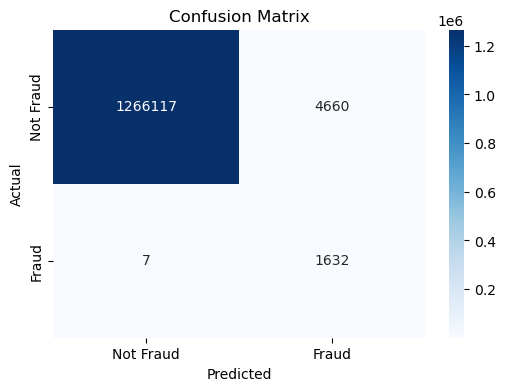

In [255]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()





In [256]:
'''✅ Total transactions  : 6,362,077
✅ Fraud cases         : 8,213 (0.13%)
✅ Fraud caught        : 1,632/1,639 (99.57% Recall)
✅ Missed fraud        : only 7 cases
✅ Overall Accuracy    : 1.00
✅ Model               : XGBoost + Pipeline'''

'✅ Total transactions  : 6,362,077\n✅ Fraud cases         : 8,213 (0.13%)\n✅ Fraud caught        : 1,632/1,639 (99.57% Recall)\n✅ Missed fraud        : only 7 cases\n✅ Overall Accuracy    : 1.00\n✅ Model               : XGBoost + Pipeline'

In [257]:
import pickle 
import os
os.makedirs('C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/models',exist_ok=True)

In [258]:
pickle.dump(pipe,open('C:/Users/vedan/OneDrive/Desktop/End to End projects/SMART_Banking_System/models/fraud_model.pkl','wb'))
print("Model Saved Successfully")

Model Saved Successfully
